# Pandas Plotting Basics


In [3]:
# %pip install pandas numpy     ### ensure pandas and numpy are installed; uncomment when done
# %pip install matplotlib       ### ensure matplotlib is installed; uncomment when done

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt ### because pandas.plot is still matplotlib
# %matplotlib inline            ### uncomment if using Jupyter Notebook
                                ### unless using Jupyter < 7
                                ### use plt.show() to display plots in other environments  

<!-- # Sample DataFrames for demonstration
import numpy as np

# Create sample data for examples
np.random.seed(42)

df1 = pd.DataFrame({
    'A': np.random.randn(100),
    'B': np.random.randn(100),
    'C': np.random.randn(100)
})

# Use positive values to support stacked area plots
df2 = pd.DataFrame({
    'a': np.random.rand(50),
    'b': np.random.rand(50),
    'c': np.random.rand(50)
}) -->

## Overview

Pandas offers a simple, high-level interface for creating plots directly from Series and DataFrame objects. It builds on Matplotlib behind the scenes, allowing you to make quick, readable plots with calls like `df.plot()` or `series.plot()`. You can easily produce line, bar/stacked bar, area, scatter, box, histogram, KDE, hexbin, and pie charts while using your **index** (including datetime) and **column labels**. 

### The `.plot()` Method

`.plot()`, a wrapper around Matplotlib's `plt.plot()`, is the primary top-level plotting method in pandas, which uses the `kind` **keyword argument** to access a variety of plotting methods including:

- `bar` or `barh` for bar plots
- `hist` for histogram
- `box` for boxplot
- `kde’ or `density` for density plots
- `area` for area plots
- `scatter` for scatter plots
- `hexbin` for hexagonal bin plots
- `pie` for pie plots

### The Plotting Methods (**`df.plot.<kind>`**)

Instead of the `kind=` arguments, your can use the plotting methods directly by using the **`df.plot.<kind>`** syntax, which makes it easier to find other plot methods. In the Python shell, you hit the tab key after df.plot., and in Jupyter, you just type til the dot and the menu with the methods will show up.

```bash
(.venv) tcn85✪mstː~/workspace/dsm$ python
Python 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
```
```python
>>> import pandas as pd
>>> df = pd.DataFrame()
>>> df.plot.<TAB>
df.plot.area(     df.plot.box(      df.plot.hist(     df.plot.pie(      
df.plot.bar(      df.plot.density(  df.plot.kde(      df.plot.scatter(  
df.plot.barh(     df.plot.hexbin(   df.plot.line(  
```

### Sample Plots

For example, here we have a piece of randomly generated time series data to plot using `.plot()`, which by default gives you a **line plot**. Because the index consists of dates, `.plot()` calls `gcf().autofmt_xdate()` to try to format the x-axis. 

Text(0.5, 1.0, 'Random Walk Simulation')

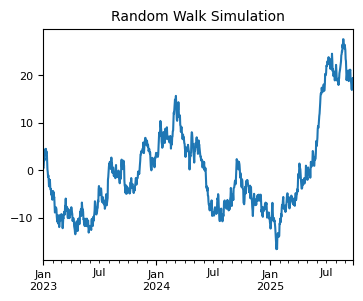

In [4]:
np.random.seed(42)  ### for reproducibility
n = 1000            ### number of time points
ts = pd.Series(np.random.randn(n), index=pd.date_range("2023-01-01", periods=n))
ts = ts.cumsum()    ### cumulative sum to create a random walk

ax = ts.plot(figsize=(4, 3), fontsize=8)  ### plot the entire time series
ax.set_title("Random Walk Simulation", fontsize=10)

For DataFrames, `.plot()` plots all of the columns with labels.

<Figure size 640x480 with 0 Axes>

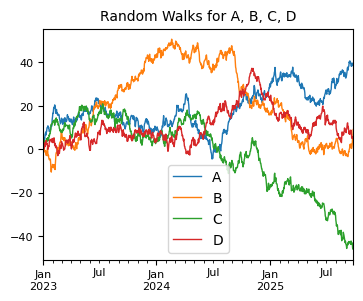

In [5]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index, columns=list("ABCD"))
df = df.cumsum()
plt.figure();
df.plot(figsize=(4, 3), lw=1, fontsize=8);  ### plot all columns together
plt.title("Random Walks for A, B, C, D", fontsize=10);

Or you can pick columns of your choice to plot.

          B         C  A
0 -0.423760 -0.453414  0
1 -2.219403 -0.783504  1
2 -1.486574 -2.057736  2


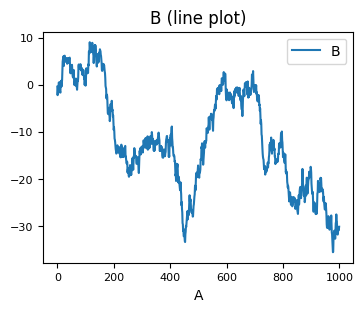

In [6]:
df1 = pd.DataFrame(np.random.randn(1000, 2), columns=["B", "C"]).cumsum()
df1["A"] = pd.Series(list(range(len(df1))))
print(df1.head(3))
df1.plot(x="A", y="B", figsize=(4, 3), fontsize=8, title="B (line plot)");

A histogram can be create with `pd.plot(kind="hist")`. Here we use the **`kind=`** keyword argument to specify the type of plot.

                   A         B         C         D
2023-01-01  1.399355  0.924634  0.059630 -0.646937
2023-01-02  2.097579  1.318119  0.954824 -0.011765
2023-01-03  3.147131  0.782884  2.272218  0.185835
2023-01-04  5.222392  0.093696  4.008181  0.383745
2023-01-05  4.570974 -0.390190  3.687834  0.807911


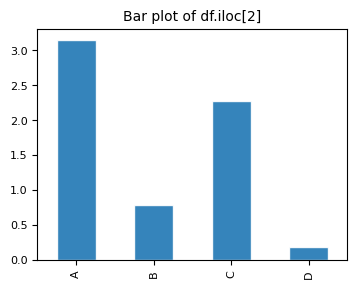

In [7]:
print(df.head())
# plt.figure();
df.iloc[2].plot(kind="bar", figsize=(4, 3), 
        title="Bar plot of df.iloc[2] (using 'kind' argument)", 
        edgecolor="white",
        alpha=0.9,
        fontsize=8);
plt.title("Bar plot of df.iloc[2]", fontsize=10);

We can use the `.plot(kind=)` syntax to generate plots other than the default line plot. For example, a histogram. 

<Axes: title={'center': 'Histogram of ts'}, ylabel='Frequency'>

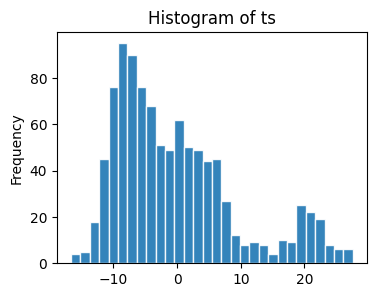

In [8]:
ts.plot(kind="hist", bins=30, figsize=(4, 3),
        title="Histogram of ts",
        edgecolor="white",
        alpha=0.9)

The same plot can be produced using the **`plot.hist()`** method. 

<Axes: title={'center': 'Histogram of ts (using method)'}, ylabel='Frequency'>

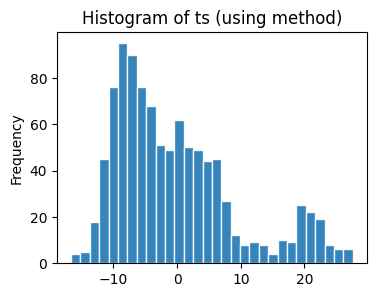

In [9]:
ts.plot.hist(bins=30, figsize=(4, 3),
             title="Histogram of ts (using method)",
             edgecolor="white",
             alpha=0.9)

For example, for histograms:
    1. `df.plot.hist()`: Uses Pandas’ unified `.plot()` interface (which wraps Matplotlib) to draw a histogram.
    2. `df.plot(kind='hist')`: The same as df.plot.hist(); a generic form of the same call.
    3. Pandas has two top-level plotting methods: `df.hist()` (a quick wrapper around Matplotlib’s `plt.hist()` for all numeric columns) and `df.boxplot()`.



| # | Method                 | Applies to          | Subplots              | Overlays Multiple Columns | Based On                 | Typical Use                           |
|:-:|:---------------------- |:------------------- |:--------------------- |:------------------------- |:------------------------ |:------------------------------------- |
| 1 | `df.hist()`            | DataFrame only      | Yes (grid of plots) | No                      | `plt.hist()`             | Quick overview of all numeric columns |
| 2 | `df.plot.hist()`       | DataFrame or Series | Single plot         | Yes                     | Pandas `.plot()` wrapper | Custom, combined histograms           |



2. **Custom parameters**: Most plotting calls accept `Matplotlib` keyword arguments and return a Matplotlib Axes object for further customization. Often used parameters from pandas API reference ([pandas.DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)) include:
   1. `data`: Series or DataFrame. The object for which the method is called.
   2. `x`: label or position, default None. Only used if data is a DataFrame.
   3. `y`: label, position or list of label, positions, default None. Allows plotting of one column versus another. Only used if data is a DataFrame.
   4. `kind`: str. The kind of plot to produce: line (default), bar, barh, hist, box, kde/density, area, pie, scatter (DataFrame only), hexbin (DataFrame only).
   5. `ax`
   6. `figsize` 
   7. `use_index`
   8. `title`
   9. ticks (xticks and yticks): sequence. Values to use for ticks. 
   10. lim (`xlim` and `ylim`): 2-tuple/list. Set the limits of the axes.    
   11. label (`xlabel` and `ylabel`: Name to use for the label on axis (default to index name).
   12. `coloarmap`: str or matplotlib colormap object
   13. `stacked`: bool, default False in line and bar plots, and True in area plot. If True, create stacked plot.
   14. **kwargs ([matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)): 
       1.  `lw` 
       2.  `alpha` 
  

3. **style sheets**: Style the plots to look globally with `plt.style.use(...)`.
  
4. **color & size**: 
    - For scatter plots you can color by a column (`c`) or 
    - size by an array (`s=df['col']*scale`) and 
    - use `cmap` for colormaps.

5. **fine-tuning**: For large or dense data, consider hexbin or KDE plots instead of scatter.

6. **Plot Types**
The `pandas.DataFrame.plot` API lists 11 plots to be used with the `kind` parameter: The kind of plot to produce: `line`(default), `bar`, `barh` (horizontal bar plot), `hist`, `box`, `kde` (`density`), `area`, `pie`, `scatter`, `hexbin`. These plots can be summarized as:


| # | Method | Shorthand | Description | Best For |
|---|--------|-----------|-------------|----------|
| 1 | `.plot(kind='line')` | `.plot.line()` | Line plot | Time series, continuous trends |
| 2 | `.plot(kind='bar')` | `.plot.bar()` | Vertical bar chart | Comparing categories side by side |
| 3 | `.plot(kind='barh')` | `.plot.barh()` | Horizontal bar chart | Long category names, rankings |
| 4 | `.plot(kind='hist')` | `.plot.hist()` | Histogram | Distribution of a single variable |
| 5 | `.plot(kind='box')` | `.plot.box()` | Box plot | Spotting outliers, comparing spread |
| 6 | `.plot(kind='kde')` | `.plot.kde()` | KDE curve | Smooth distribution, comparing shapes |
| 7 | `.plot(kind='density')` | `.plot.density()` | Alias for kde | Same as KDE |
| 8 | `.plot(kind='area')` | `.plot.area()` | Area plot | Cumulative totals, part-to-whole over time |
| 9 | `.plot(kind='pie')` | `.plot.pie()` | Pie chart | Proportions of a whole (few categories) |
| 10 | `.plot(kind='scatter', x='col1', y='col2')` | `.plot.scatter(x='col1', y='col2')` | Scatter plot | Correlation between two numeric variables |
| 11 | `.plot(kind='hexbin', x='col1', y='col2')` | `.plot.hexbin(x='col1', y='col2')` | Hexbin plot | Large datasets, 2D density visualization |

**Notes:**
- `kde` and `density` are aliases — same plot, counted once for unique types
- `scatter` and `hexbin` **require** `x` and `y` arguments
- `pie` requires a single column (`y=` or per-column)
- `scatter` and `hexbin` are **DataFrame only**

<!-- Tips:
- Use the returned Axes for annotation, legends, and fine control (ax.set_title, ax.set_xlabel, etc.).
- Combine pandas plotting with Matplotlib calls for publication-quality figures.
- When plotting many subplots, consider subplots=True and sharex/sharey for consistent axes. -->

Note: Jupyter Notebooks enable inline plotting (no pop-up) with `%matplotlib inline`, which is an IPython magic command that tells Jupyter Notebook to render Matplotlib plots directly inside the notebook output cell instead of in a separate window. You don’t need %matplotlib inline in Jupyter environment with IPython >= 7.

Later, when you learn Matplotlib, you will see why these methods of plotting are a lot easier to use. Pandas visualization balances ease of use with control over the figure. A lot of the plot calls also accept additional arguments of their parent matplotlib.plt call. 
